In [1]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append('ipynb/location/packages')

# Linear program

In [3]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        return

    x = solver.NumVar(0, solver.infinity(), "x")
    y = solver.NumVar(0, solver.infinity(), "y")

    solver.Add(x + 2 * y <= 14.0)
    solver.Add(3 * x - y >= 0.0)
    solver.Add(x - y <= 2.0)
    solver.Maximize(3 * x + 4 * y)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x = {x.solution_value():0.1f}")
        print(f"y = {y.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 34.0
x = 6.0
y = 4.0


In [4]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x1 = {x1.solution_value():0.1f}")
        print(f"x2 = {x2.solution_value():0.1f}")
        print(f"x3 = {x3.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


# Integer program

In [5]:
import numpy as np

In [6]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


$$
\max z = 16 x_1 + 22 x_2 + 12 x_3 + 8 x_4
\\
\begin{cases}
5 x_1 + 7 x_2 + 4 x_3 + 3 x_4 \leq 14 \\
x_j = {0, 1}
\end{cases}
$$

In [7]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")
    x4 = solver.IntVar(0.0, infinity, "x4")

    solver.Add(5 * x1 + 7 * x2 + 4 * x3 + 3 * x4 <= 14)
    solver.Add(x1 <= 1)
    solver.Add(x2 <= 1)
    solver.Add(x3 <= 1)
    solver.Add(x4 <= 1)
    solver.Maximize(16 * x1 + 22 * x2 + 12 * x3 + 8 * x4)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
        print("x4 =", x4.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 42.0
x1 = 0.0
x2 = 1.0
x3 = 1.0
x4 = 1.0


In [8]:
from packages.ortool import programing_const

## Plant location

### Balinski model

$$
\min z = \sum_{i,j} c_{ij} x_{ij} + \sum_{i} f_i y_i , \\
\begin{cases}
&\sum_i x_{ij} = 1, \quad &(j=\overline{1,n}) \\
&0 \leq x_{ij} \leq y_i \leq 1, \quad &(i=\overline{1,m}, \: j=\overline{1,n})\\
&y_i={0,1} \quad &(i=\overline{1,m})
\end{cases}
$$

### Model testing

In [9]:
from packages.GraphView import Graph

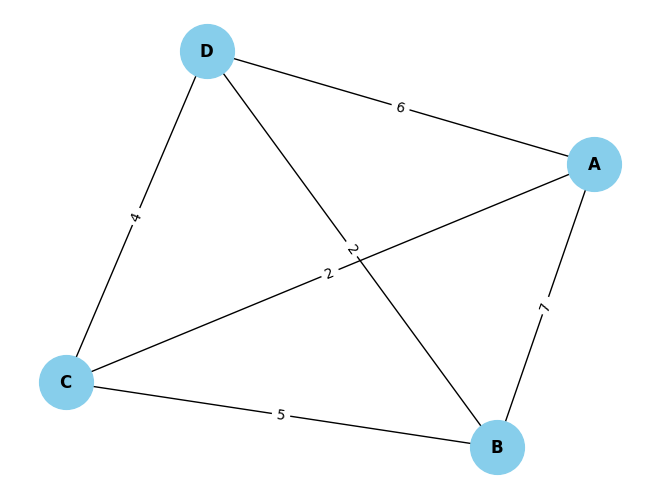

In [10]:
Global = [
    [0, 7, 2, 6],
    [7, 0, 5, 2],
    [2, 5, 0, 4],
    [6, 2, 4, 0]
]
df = Graph(Global)
df.show()

#### Balinski model

$$
\min z = 0x_{11}+7x_{12}+2x_{13}+6x_{14}\\
+7x_{21}+0x_{22}+5x_{23}+2x_{24}\\
+2x_{31}+5x_{32}+0x_{33}+4x_{34}\\
+6x_{41}+2x_{42}+4x_{43}+0x_{44}\\
\\
\\
\\
\begin{cases}
&x_{11}+x_{12}+x_{13}+x_{14}=1\\
&x_{21}+x_{22}+x_{23}+x_{24}=1\\
&x_{31}+x_{32}+x_{33}+x_{34}=1\\
&x_{41}+x_{42}+x_{43}+x_{44}=1\\
\\
&x_{11}+x_{22}+x_{33}+x_{44}=1\\
\\
&x_{21}\le x_{11},\\
&x_{31}\le x_{11},\\
&x_{41}\le x_{11},\\
\\
&x_{12}\le x_{22},\\
&x_{32}\le x_{22},\\
&x_{42}\le x_{22},\\
\\
&x_{13}\le x_{33},\\
&x_{23}\le x_{33},\\
&x_{43}\le x_{33},\\
\\
&x_{14}\le x_{44},\\
&x_{24}\le x_{44},\\
&x_{34}\le x_{44},\\
\\
&x_{11},x_{12},x_{13},x_{14},x_{21},x_{22},x_{23},x_{24},x_{31},x_{32},x_{33},x_{34}\ge 0\\
\end{cases}
$$

##### Python solving

In [11]:
df = programing_const(
        cost_matrix=[
            [0, 7, 2, 6],
            [7, 0, 5, 2],
            [2, 5, 0, 4],
            [6, 2, 4, 0]
        ],
        p_facility=2,
        constraint_co_leq=[
            [0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1],
            [-1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, -1],
            [-1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, -1],
            [-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0]
        ],
        bounds_leq=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        num_constraints_leq=12
    )

Detail output

In [12]:
df.solver(is_maximization=False, is_integer=True)

Number of variables = 16
Solving with CP-SAT solver v9.14.6206
Objective value = 4.0
x[0]  =  0.0
x[1]  =  0.0
x[2]  =  1.0
x[3]  =  0.0
x[4]  =  0.0
x[5]  =  1.0
x[6]  =  0.0
x[7]  =  0.0
x[8]  =  0.0
x[9]  =  0.0
x[10]  =  1.0
x[11]  =  0.0
x[12]  =  0.0
x[13]  =  1.0
x[14]  =  0.0
x[15]  =  0.0

Solution matrix:
[0.0, 0.0, 1.0, 0.0]
[0.0, 1.0, 0.0, 0.0]
[0.0, 0.0, 1.0, 0.0]
[0.0, 1.0, 0.0, 0.0]

Problem solved in 5 milliseconds
Problem solved in 0 iterations
Problem solved in 0 branch-and-bound nodes
